# Demo 2 - Text Classification: 3 Ways
## NLP Session - Part 2

---

**What we will do in this demo:**

We take the IMDb movie review dataset and train three different classifiers on it.
Each approach gets more powerful but also more complex.
At the end we compare their accuracy side by side.

| Approach | Method | What makes it special |
|----------|--------|-----------------------|
| 1 | Logistic Regression + TF-IDF | Fast, interpretable, classic ML |
| 2 | Simple LSTM | Neural network that reads word sequences |
| 3 | Pretrained DistilBERT | State-of-the-art transformer, zero training needed |

**Key idea:** All three models see the same dataset and answer the same question -
is this movie review positive or negative?

---

## Step 0 - Install Libraries and Load the Dataset

We need three libraries:

- `scikit-learn` - for Logistic Regression and TF-IDF (Approach 1)
- `tensorflow` and `keras` - for the LSTM neural network (Approach 2)
- `transformers` - for the pretrained DistilBERT model (Approach 3)

We also use the IMDb dataset that ships directly inside `tensorflow.keras.datasets`.
No manual download needed.

In [1]:
# Install the libraries we need
# This may take 1-2 minutes on first run

!pip install scikit-learn --quiet
!pip install tensorflow --quiet
!pip install transformers --quiet

print("All libraries installed.")

All libraries installed.


In [2]:
# Import everything we need
# We import at the top so all code cells below can use these

import numpy as np
import warnings
warnings.filterwarnings("ignore")   # hide unnecessary warnings

# For Approach 1 - classic ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

# For Approach 2 - LSTM
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# For Approach 3 - DistilBERT
from transformers import pipeline

print("All imports successful.")
print("TensorFlow version:", tf.__version__)

All imports successful.
TensorFlow version: 2.20.0


---
## Step 1 - Understand the Dataset

**What is the IMDb dataset?**

The IMDb dataset contains 50,000 real movie reviews from the Internet Movie Database.
Each review is already labeled:

- Label 1 = Positive review
- Label 0 = Negative review

The dataset is split 50/50 into training and test sets:

| Split | Size | Purpose |
|-------|------|--------|
| Train | 25,000 reviews | Model learns from these |
| Test | 25,000 reviews | We evaluate on these - model has never seen them |

This is a **binary classification** task - two possible outputs: positive or negative.

In [3]:
# Load the IMDb dataset
# The dataset is stored as integer sequences inside Keras
# Each integer represents one word in a vocabulary of 10,000 words

NUM_WORDS = 10000   # keep only the 10,000 most common words

(x_train_seq, y_train), (x_test_seq, y_test) = imdb.load_data(num_words=NUM_WORDS)

print("Dataset loaded successfully.")
print()
print(f"Training reviews: {len(x_train_seq)}")
print(f"Test reviews:     {len(x_test_seq)}")
print()
print(f"Label 0 = Negative,  Label 1 = Positive")
print(f"Positive reviews in train: {y_train.sum()}")
print(f"Negative reviews in train: {len(y_train) - y_train.sum()}")
print()
print("The dataset is perfectly balanced - equal positive and negative reviews.")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset loaded successfully.

Training reviews: 25000
Test reviews:     25000

Label 0 = Negative,  Label 1 = Positive
Positive reviews in train: 12500
Negative reviews in train: 12500

The dataset is perfectly balanced - equal positive and negative reviews.


In [4]:
# The raw dataset stores reviews as integer sequences
# Each integer is a word index in the vocabulary
# We need to convert them back to actual English words

# Load the word index - a dictionary mapping words to integers
word_index = imdb.get_word_index()

# The index is offset by 3 reserved positions
index_to_word = {v + 3: k for k, v in word_index.items()}
index_to_word[0] = "[PAD]"    # padding token
index_to_word[1] = "[START]"  # start of sequence
index_to_word[2] = "[UNK]"    # unknown word
index_to_word[3] = "[UNUSED]"

def decode_review(sequence):
    """Convert a list of integers back into readable English text."""
    return " ".join(index_to_word.get(i, "?") for i in sequence)


# Show the first review in human-readable form
print("First training review (decoded to text):")
print("-" * 60)
print(decode_review(x_train_seq[0]))
print("-" * 60)
print(f"Label: {y_train[0]}  -->  {"POSITIVE" if y_train[0] == 1 else "NEGATIVE"}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
First training review (decoded to text):
------------------------------------------------------------
[START] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [UNK] is an amazing actor and now the same being director [UNK] father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for [UNK] and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also [UNK] to the two little boy's that played the [UNK] of norman and paul they were just brilliant children are often left out of the [UNK] list i thi

In [5]:
# Show a few more examples so we get a feel for the data

print("Sample reviews from the training set:")
print()

for i in [0, 1, 2, 5]:
    label = "POSITIVE" if y_train[i] == 1 else "NEGATIVE"
    text = decode_review(x_train_seq[i])
    # Show only the first 120 characters to keep it readable
    print(f"Review {i+1} [{label}]:")
    print(f"  {text[:120]}...")
    print()

Sample reviews from the training set:

Review 1 [POSITIVE]:
  [START] this film was just brilliant casting location scenery story direction everyone's really suited the part they pla...

Review 2 [NEGATIVE]:
  [START] big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i l...

Review 3 [NEGATIVE]:
  [START] this has to be one of the worst films of the 1990s when my friends i were watching this film being the target au...

Review 6 [NEGATIVE]:
  [START] begins better than it ends funny that the russian submarine crew [UNK] all other actors it's like those scenes w...



---
## Approach 1 - Logistic Regression + TF-IDF

**What is this approach?**

This is the classic machine learning approach to text classification.

It works in two stages:

**Stage 1 - TF-IDF (convert text to numbers)**

TF-IDF stands for Term Frequency - Inverse Document Frequency.
It converts each review into a vector of numbers where:
- Words that appear often in THIS review get a high score
- Words that appear in EVERY review (like 'the', 'a') get a low score
- Rare but meaningful words (like 'breathtaking') get a high score

**Stage 2 - Logistic Regression (learn from labeled examples)**

Logistic Regression learns a weight (importance score) for each word.
Words like 'excellent' and 'masterpiece' get high positive weights.
Words like 'awful' and 'boring' get high negative weights.
For a new review, it sums the weights and predicts positive or negative.

**Advantage:** Fast to train (seconds), easy to interpret, strong baseline.

In [36]:
# For Approach 1 we need plain text, not integer sequences
# Decode all training and test reviews back to English

print("Decoding reviews back to text...")
x_train_text = [decode_review(seq) for seq in x_train_seq]
x_test_text  = [decode_review(seq) for seq in x_test_seq]

print(f"Training texts: {len(x_train_text)}")
print(f"Test texts:     {len(x_test_text)}")
print()
print("Example decoded review:")
print(x_train_text[0][:200], "...")

Decoding reviews back to text...
Training texts: 25000
Test texts:     25000

Example decoded review:
[START] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [UNK] is an amazing actor and  ...


In [37]:
# Build the TF-IDF vectorizer
# It converts each review into a numeric vector

tfidf = TfidfVectorizer(
    max_features=20000,    # keep only the 20,000 most important words
    ngram_range=(1, 2),    # use single words AND word pairs (bigrams)
    min_df=2,              # ignore words that appear in fewer than 2 reviews
    sublinear_tf=True,     # apply log scaling to word counts
)

# fit_transform learns the vocabulary from training data and converts it
# This may take 10-15 seconds
print("Learning vocabulary from training reviews...")
x_train_tfidf = tfidf.fit_transform(x_train_text)

# transform applies the same vocabulary to test data
# IMPORTANT: we never fit on test data - that would be cheating
x_test_tfidf  = tfidf.transform(x_test_text)

print(f"Training matrix shape: {x_train_tfidf.shape}")
print(f"  This means: {x_train_tfidf.shape[0]} reviews x {x_train_tfidf.shape[1]} word features")

Learning vocabulary from training reviews...
Training matrix shape: (25000, 20000)
  This means: 25000 reviews x 20000 word features


In [38]:
# What does TF-IDF actually look like? Let us inspect one review

import numpy as np

# Get the feature names (words/bigrams)
feature_names = tfidf.get_feature_names_out()

# Look at the first review
review_vector = x_train_tfidf[0].toarray()[0]

# Find the top 10 words with highest TF-IDF scores for this review
top_indices = np.argsort(review_vector)[::-1][:10]

label = "POSITIVE" if y_train[0] == 1 else "NEGATIVE"
print(f"Review label: {label}")
print()
print("Top 10 words by TF-IDF score for this review:")
print()
print(f"  {"Word / Phrase":<30} {"TF-IDF Score"}")
print("  " + "-" * 45)
for idx in top_indices:
    if review_vector[idx] > 0:
        print(f"  {feature_names[idx]:<30} {review_vector[idx]:.4f}")

Review label: POSITIVE

Top 10 words by TF-IDF score for this review:

  Word / Phrase                  TF-IDF Score
  ---------------------------------------------
  children are                   0.1687
  brilliant                      0.1215
  amazing                        0.1193
  what they                      0.1102
  was just                       0.1036
  was so                         0.0998
  unk list                       0.0991
  true and                       0.0989
  fact there                     0.0989
  could just                     0.0989


In [39]:
# Train Logistic Regression
# This is the step where the model actually learns

lr_model = LogisticRegression(
    max_iter=1000,     # maximum number of training iterations
    C=1.0,            # regularization strength (controls overfitting)
    solver="lbfgs",   # optimization algorithm
)

print("Training Logistic Regression...")
lr_model.fit(x_train_tfidf, y_train)
print("Training complete.")

Training Logistic Regression...
Training complete.


In [40]:
# Evaluate on the test set

y_pred_lr = lr_model.predict(x_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Test Accuracy: {acc_lr:.4f}  ({acc_lr*100:.1f}%)")
print()
print("Full classification report:")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Negative", "Positive"]))

Logistic Regression Test Accuracy: 0.8978  (89.8%)

Full classification report:

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90     12500
    Positive       0.89      0.91      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



In [11]:
# Interpretability - what did the model actually learn?
# Logistic Regression assigns a weight to every word
# High positive weight = strong signal for POSITIVE review
# High negative weight = strong signal for NEGATIVE review

coefficients = lr_model.coef_[0]
feature_names = tfidf.get_feature_names_out()

# Sort by coefficient value
sorted_indices = np.argsort(coefficients)

# Top positive words
top_positive_idx = sorted_indices[-15:]
top_positive_idx = top_positive_idx[::-1]

# Top negative words
top_negative_idx = sorted_indices[:15]

print("Words most associated with POSITIVE reviews:")
print()
print(f"  {"Word":<30} {"Weight (higher = more positive)"}")
print("  " + "-" * 55)
for idx in top_positive_idx:
    print(f"  {feature_names[idx]:<30} +{coefficients[idx]:.3f}")

print()
print("Words most associated with NEGATIVE reviews:")
print()
print(f"  {"Word":<30} {"Weight (lower = more negative)"}")
print("  " + "-" * 55)
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:<30} {coefficients[idx]:.3f}")

Words most associated with POSITIVE reviews:

  Word                           Weight (higher = more positive)
  -------------------------------------------------------
  great                          +6.793
  excellent                      +5.426
  perfect                        +4.479
  wonderful                      +4.361
  amazing                        +3.781
  the best                       +3.767
  best                           +3.739
  fun                            +3.408
  love                           +3.359
  today                          +3.337
  loved                          +3.211
  superb                         +3.029
  well                           +3.025
  brilliant                      +3.005
  favorite                       +2.946

Words most associated with NEGATIVE reviews:

  Word                           Weight (lower = more negative)
  -------------------------------------------------------
  bad                            -7.537
  worst               

In [12]:
# Try Approach 1 on brand new reviews we write ourselves

new_reviews = [
    "This film was absolutely brilliant. The acting and story were outstanding.",
    "Terrible movie. Complete waste of time. The plot made no sense at all.",
    "The visuals were stunning but the storyline was disappointingly weak.",
    "One of the best films I have ever seen. A true masterpiece of cinema.",
]

# Transform using the SAME vectorizer we trained on
new_reviews_tfidf = tfidf.transform(new_reviews)
predictions = lr_model.predict(new_reviews_tfidf)
probabilities = lr_model.predict_proba(new_reviews_tfidf)

print("Predictions on new reviews:")
print()
for review, pred, prob in zip(new_reviews, predictions, probabilities):
    label = "POSITIVE" if pred == 1 else "NEGATIVE"
    confidence = max(prob) * 100
    print(f"  Review: {review[:70]}...")
    print(f"  Prediction: {label}  (confidence: {confidence:.1f}%)")
    print()

Predictions on new reviews:

  Review: This film was absolutely brilliant. The acting and story were outstand...
  Prediction: POSITIVE  (confidence: 73.8%)

  Review: Terrible movie. Complete waste of time. The plot made no sense at all....
  Prediction: NEGATIVE  (confidence: 99.4%)

  Review: The visuals were stunning but the storyline was disappointingly weak....
  Prediction: NEGATIVE  (confidence: 67.3%)

  Review: One of the best films I have ever seen. A true masterpiece of cinema....
  Prediction: POSITIVE  (confidence: 96.2%)



---
## Approach 2 - Simple LSTM Neural Network

**What is this approach?**

An LSTM (Long Short-Term Memory) is a type of neural network designed to read sequences.
Unlike Approach 1 which treated each word independently, an LSTM reads words one at a time
and remembers context as it goes.

**How it works - step by step:**

```
Input:  "The movie was not good at all"

Step 1 - Embedding layer:
  Each word is converted to a vector of 64 numbers
  The model learns what each word means during training

Step 2 - LSTM layer:
  Reads the word vectors one by one, left to right
  Maintains a memory of what it has read so far
  After reading 'not', the memory knows negation is coming
  After reading 'good', it knows this was negated

Step 3 - Dense layer:
  Takes the final LSTM memory state
  Outputs a single number between 0 and 1
  Above 0.5 = POSITIVE, below 0.5 = NEGATIVE
```

**Advantage over Approach 1:** Understands word ORDER and can handle negation better.

**Disadvantage:** Slower to train, needs a GPU for reasonable speed.

# LSTM

In [13]:
# For LSTM we use the integer sequences we already have
# but we need all sequences to be the same length
# Shorter reviews are padded with zeros at the front
# Longer reviews are cut off at 400 words

MAX_LEN = 400   # maximum number of words per review

x_train_padded = pad_sequences(x_train_seq, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test_padded  = pad_sequences(x_test_seq,  maxlen=MAX_LEN, padding="pre", truncating="pre")

print(f"Shape after padding:")
print(f"  Training: {x_train_padded.shape}  (25000 reviews x 400 words each)")
print(f"  Test:     {x_test_padded.shape}")
print()
print("Example: first 20 values of the first padded review:")
print(x_train_padded[0][:20])
print("The zeros at the front are padding - they fill the space before the review starts.")

Shape after padding:
  Training: (25000, 400)  (25000 reviews x 400 words each)
  Test:     (25000, 400)

Example: first 20 values of the first padded review:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
The zeros at the front are padding - they fill the space before the review starts.


In [14]:
# Build the LSTM model
# We stack three types of layers

VOCAB_SIZE   = NUM_WORDS    # 10,000 unique words
EMBED_DIM    = 64           # each word becomes a vector of 64 numbers
LSTM_UNITS   = 64           # the LSTM remembers 64 things at each step

lstm_model = Sequential([

    # Layer 1 - Embedding
    # Maps each word integer to a dense vector of numbers
    # The model learns these vectors during training
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN
    ),

    # Layer 2 - Dropout
    # Randomly turns off 20% of connections during training
    # This prevents the model from memorising the training data (overfitting)
    Dropout(0.2),

    # Layer 3 - LSTM
    # Reads the word sequence and builds up a memory state
    LSTM(LSTM_UNITS),

    # Layer 4 - Dropout again for regularization
    Dropout(0.2),

    # Layer 5 - Dense output layer
    # Produces a single number between 0 and 1
    # 0.0 = very negative, 1.0 = very positive
    Dense(1, activation="sigmoid"),

])

# Compile: choose how the model measures error and how it updates weights
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",   # standard loss for binary classification
    metrics=["accuracy"]
)

print("LSTM model architecture:")
print()
lstm_model.summary()

LSTM model architecture:



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train the LSTM
# On CPU this takes about 15-20 minutes
# On a free Google Colab GPU it takes about 2-3 minutes

print("Training LSTM...")
print("Tip: open this on Google Colab with GPU for faster training.")
print()

history = lstm_model.fit(
    x_train_padded, y_train,
    epochs=5,             # pass through the full training data 3 times
    batch_size=128,       # process 128 reviews at once before updating weights
    validation_split=0.1, # hold out 10% of training data to monitor progress
    verbose=1
)

print()
print("Training complete.")

Training LSTM...
Tip: open this on Google Colab with GPU for faster training.

Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9805 - loss: 0.0597 - val_accuracy: 0.8568 - val_loss: 0.5326
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9640 - loss: 0.0965 - val_accuracy: 0.8480 - val_loss: 0.5686
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9925 - loss: 0.0268 - val_accuracy: 0.8596 - val_loss: 0.7329
Epoch 4/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9894 - loss: 0.0331 - val_accuracy: 0.8412 - val_loss: 0.6080
Epoch 5/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9900 - loss: 0.0323 - val_accuracy: 0.8664 - val_loss: 0.6647
Epoch 6/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9921 - loss: 0.0266 - val_accuracy: 0.8620 - val_loss: 0.7407
Epoch 7/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9949 - loss: 0.0192 - val_accuracy: 0.8668 - val_loss: 0.7643
Epoch 8/25
176/176

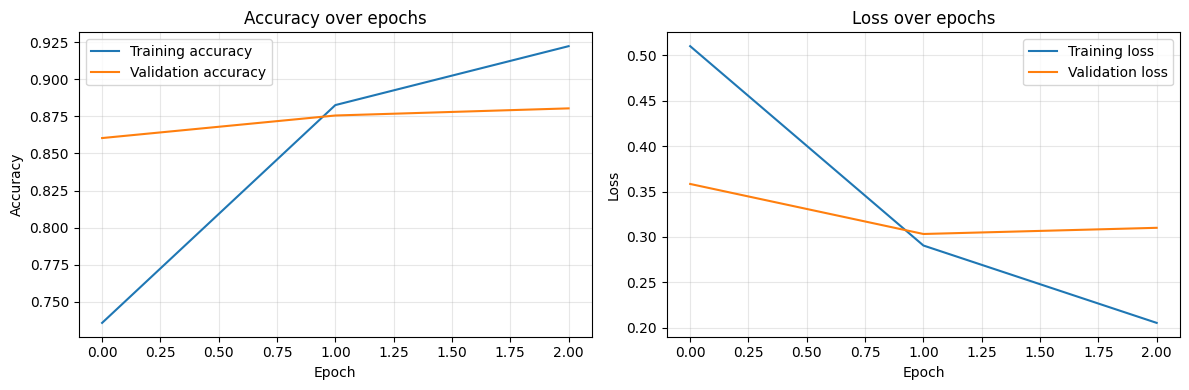


Reading the plots:
  Training accuracy should rise over epochs - model is learning.
  If validation accuracy diverges from training, the model is overfitting.


In [16]:
# Plot training history so we can see if the model learned well

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history["accuracy"],     label="Training accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history["loss"],     label="Training loss")
axes[1].plot(history.history["val_loss"], label="Validation loss")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_training_history.png", dpi=100, bbox_inches="tight")
plt.show()

print()
print("Reading the plots:")
print("  Training accuracy should rise over epochs - model is learning.")
print("  If validation accuracy diverges from training, the model is overfitting.")

In [17]:
# Evaluate on test set

loss_lstm, acc_lstm = lstm_model.evaluate(x_test_padded, y_test, verbose=0)

print(f"LSTM Test Accuracy: {acc_lstm:.4f}  ({acc_lstm*100:.1f}%)")
print(f"LSTM Test Loss:     {loss_lstm:.4f}")

LSTM Test Accuracy: 0.8758  (87.6%)
LSTM Test Loss:     0.3160


## LSTM (Bidirectional)

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

VOCAB_SIZE  = NUM_WORDS
EMBED_DIM   = 64
LSTM_UNITS  = 32

lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    Dropout(0.4),
    Bidirectional(LSTM(LSTM_UNITS, recurrent_regularizer=l2(0.01))),
    Dropout(0.4),
    Dense(1, activation="sigmoid"),
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("LSTM model architecture:")
lstm_model.summary()

history = lstm_model.fit(
    x_train_padded, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    # callbacks=[early_stop]
)

loss_lstm, acc_lstm = lstm_model.evaluate(x_test_padded, y_test, verbose=0)

print(f"LSTM Test Accuracy: {acc_lstm:.4f}  ({acc_lstm*100:.1f}%)")
print(f"LSTM Test Loss:     {loss_lstm:.4f}")

LSTM model architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.7036 - loss: 0.7506 - val_accuracy: 0.8404 - val_loss: 0.4303
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.8712 - loss: 0.3489 - val_accuracy: 0.8584 - val_loss: 0.3615
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9041 - loss: 0.2706 - val_accuracy: 0.8568 - val_loss: 0.3858
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9195 - loss: 0.2326 - val_accuracy: 0.8620 - val_loss: 0.3842
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9366 - loss: 0.1931 - val_accuracy: 0.8612 - val_loss: 0.3609
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9335 - loss: 0.1935 - val_accuracy: 0.8660 - val_loss: 0.3944
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9492 - loss: 0.1613 - val_accuracy: 0.8640 - val_loss: 0.4103
Epoch 8/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9580 - loss: 0.1364 - val_ac

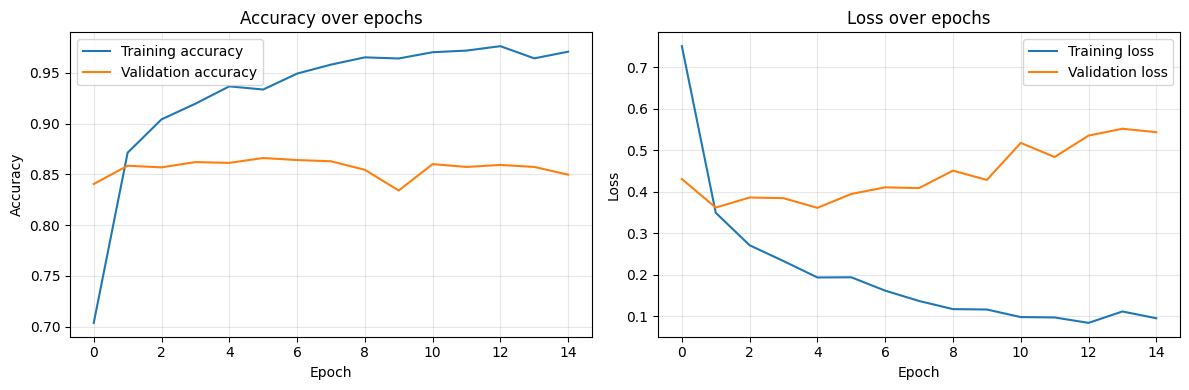


Reading the plots:
  Training accuracy should rise over epochs - model is learning.
  If validation accuracy diverges from training, the model is overfitting.


In [41]:
# Plot training history so we can see if the model learned well


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history["accuracy"],     label="Training accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history["loss"],     label="Training loss")
axes[1].plot(history.history["val_loss"], label="Validation loss")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_training_history.png", dpi=100, bbox_inches="tight")
plt.show()

print()
print("Reading the plots:")
print("  Training accuracy should rise over epochs - model is learning.")
print("  If validation accuracy diverges from training, the model is overfitting.")

# LSTM (Multilayer)

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, Conv1D, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping

VOCAB_SIZE  = NUM_WORDS
EMBED_DIM   = 128        # increased from 64
LSTM_UNITS  = 128        # increased from 32

lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    Conv1D(128, kernel_size=5, activation='relu'),  # extracts local n-gram patterns
    MaxPooling1D(pool_size=2),                       # reduces sequence length
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),  # first LSTM layer
    Dropout(0.4),
    Bidirectional(LSTM(64)),                         # second LSTM layer
    Dropout(0.4),
    Dense(64, activation='relu'),                    # extra dense layer
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("LSTM model architecture:")
lstm_model.summary()

history = lstm_model.fit(
    x_train_padded, y_train,
    epochs=2,
    batch_size=64,       # smaller batch for better generalization
    validation_split=0.1,
    # callbacks=[early_stop]
)

loss, accuracy = lstm_model.evaluate(x_test_padded, y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")

LSTM model architecture:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.7771 - loss: 0.4406 - val_accuracy: 0.8864 - val_loss: 0.2789
Epoch 2/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.9156 - loss: 0.2229 - val_accuracy: 0.8956 - val_loss: 0.2595
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8845 - loss: 0.2727

Test Accuracy: 0.8845


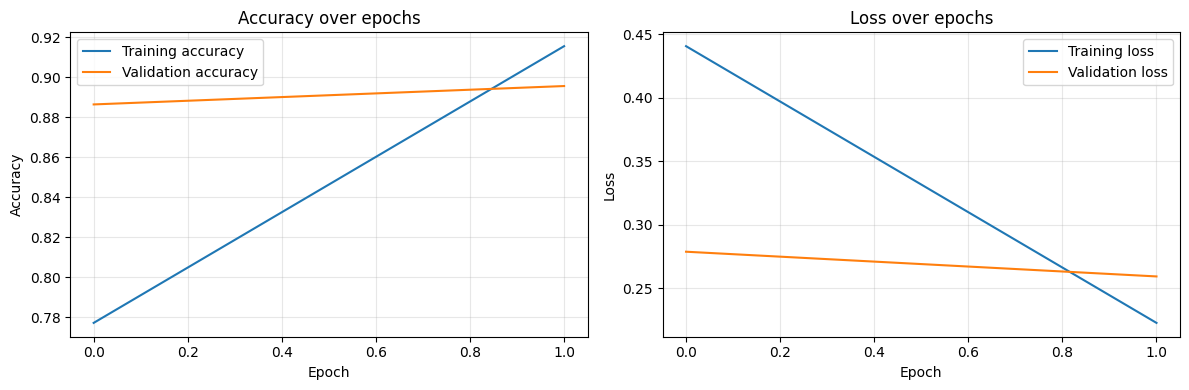


Reading the plots:
  Training accuracy should rise over epochs - model is learning.
  If validation accuracy diverges from training, the model is overfitting.


In [46]:
# Plot training history so we can see if the model learned well


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history["accuracy"],     label="Training accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history["loss"],     label="Training loss")
axes[1].plot(history.history["val_loss"], label="Validation loss")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_training_history.png", dpi=100, bbox_inches="tight")
plt.show()

print()
print("Reading the plots:")
print("  Training accuracy should rise over epochs - model is learning.")
print("  If validation accuracy diverges from training, the model is overfitting.")

In [56]:
# Evaluate on test set

loss_lstm, acc_lstm = lstm_model.evaluate(x_test_padded, y_test, verbose=0)

print(f"LSTM Test Accuracy: {acc_lstm:.4f}  ({acc_lstm*100:.1f}%)")
print(f"LSTM Test Loss:     {loss_lstm:.4f}")

LSTM Test Accuracy: 0.8845  (88.4%)
LSTM Test Loss:     0.2727


In [47]:
# Try LSTM on our own reviews
# We need to convert them using the same word index the dataset uses

def encode_review(text, word_index, max_len=400):
    """
    Converts a plain English review into a padded integer sequence
    using the IMDb word index.
    """
    # Convert text to lowercase and split into words
    words = text.lower().split()
    # Replace each word with its integer index (use 2 for unknown words)
    encoded = [word_index.get(word, 2) + 3 for word in words]
    # Pad to the right length
    padded = pad_sequences([encoded], maxlen=max_len, padding="pre")
    return padded


new_reviews = [
    "This film was absolutely brilliant. The acting and story were outstanding.",
    "Terrible movie. Complete waste of time. The plot made no sense at all.",
    "The visuals were stunning but the storyline was disappointingly weak.",
    "One of the best films I have ever seen. A true masterpiece of cinema.",
]

print("Predictions on new reviews (LSTM):")
print()
for review in new_reviews:
    encoded = encode_review(review, word_index)
    score = lstm_model.predict(encoded, verbose=0)[0][0]
    label = "POSITIVE" if score > 0.5 else "NEGATIVE"
    print(f"  Review: {review[:70]}...")
    print(f"  Score: {score:.4f}   Prediction: {label}")
    print()

Predictions on new reviews (LSTM):

  Review: This film was absolutely brilliant. The acting and story were outstand...
  Score: 0.9047   Prediction: POSITIVE

  Review: Terrible movie. Complete waste of time. The plot made no sense at all....
  Score: 0.2660   Prediction: NEGATIVE

  Review: The visuals were stunning but the storyline was disappointingly weak....
  Score: 0.8835   Prediction: POSITIVE

  Review: One of the best films I have ever seen. A true masterpiece of cinema....
  Score: 0.9655   Prediction: POSITIVE



---
## Approach 3 - Pretrained DistilBERT

**What is this approach?**

DistilBERT is a pretrained transformer model released by HuggingFace.
It has already been trained on millions of documents and has learned a deep
understanding of English language.

For sentiment analysis, we use a version that has been fine-tuned on the SST-2 dataset
(Stanford Sentiment Treebank) - a dataset of movie review sentences labeled as positive/negative.

**Why is this special?**

We are not training anything. We just load the model and ask it to predict.
The model already knows how to classify sentiment from its pre-training.
This is called **zero-shot usage** (or more precisely, using a fine-tuned checkpoint without
additional training).

**How BERT reads text differently from LSTM:**

```
Sentence: "The movie was not great at all"

LSTM reads:   The -> movie -> was -> not -> great -> at -> all
              (left to right, one word at a time)

BERT reads:   ALL words at the same time
              and uses attention to see how every word relates to every other word
              'great' is directly connected to 'not' via the attention mechanism
              so the model knows 'not great' means negative
```

**Advantage:** Highest accuracy, no training needed.

**Disadvantage:** Slower for inference, larger model file to download.

In [48]:
# Load the sentiment analysis pipeline from HuggingFace
# This downloads a pretrained DistilBERT model fine-tuned for sentiment analysis
# Download size is about 250MB - may take 1-2 minutes on first run

print("Loading DistilBERT sentiment pipeline...")
print("This downloads the model on first run. Subsequent runs are instant.")
print()

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("Model loaded successfully.")

Loading DistilBERT sentiment pipeline...
This downloads the model on first run. Subsequent runs are instant.



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully.


In [49]:
# Test it on a few examples before running the full dataset

test_sentences = [
    "This film was absolutely brilliant.",
    "Terrible movie. Complete waste of time.",
    "The visuals were stunning but the story was weak.",
    "Not the worst film I have seen but certainly not the best either.",
    "One of the greatest movies ever made.",
]

print("DistilBERT predictions:")
print()
print(f"  {"Review":<55} {"Label":<12} {"Confidence"}")
print("  " + "-" * 80)

for sentence in test_sentences:
    result = sentiment_pipeline(sentence)[0]
    label = result["label"]
    confidence = result["score"] * 100
    print(f"  {sentence[:53]:<55} {label:<12} {confidence:.1f}%")

DistilBERT predictions:

  Review                                                  Label        Confidence
  --------------------------------------------------------------------------------
  This film was absolutely brilliant.                     POSITIVE     100.0%
  Terrible movie. Complete waste of time.                 NEGATIVE     100.0%
  The visuals were stunning but the story was weak.       NEGATIVE     99.8%
  Not the worst film I have seen but certainly not the    NEGATIVE     99.5%
  One of the greatest movies ever made.                   POSITIVE     100.0%


In [52]:
SAMPLE_SIZE = 2000

x_test_sample_text = [decode_review(seq) for seq in x_test_seq[:SAMPLE_SIZE]]
y_test_sample = y_test[:SAMPLE_SIZE]

print(f"Running DistilBERT on {SAMPLE_SIZE} test reviews...")
print("Note: This is a zero-shot model (not fine-tuned on IMDb)")
print()

BATCH_SIZE = 32
bert_predictions = []

for i in range(0, SAMPLE_SIZE, BATCH_SIZE):
    batch = x_test_sample_text[i : i + BATCH_SIZE]

    # ✅ Let the tokenizer handle truncation — don't slice text manually
    results = sentiment_pipeline(batch, truncation=True, max_length=512)

    for r in results:
        bert_predictions.append(1 if r["label"] == "POSITIVE" else 0)

    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  Processed {min(i + BATCH_SIZE, SAMPLE_SIZE)}/{SAMPLE_SIZE} reviews...")

bert_predictions = np.array(bert_predictions)
acc_bert = accuracy_score(y_test_sample, bert_predictions)

print()
print(f"DistilBERT Zero-Shot Accuracy : {acc_bert*100:.1f}%")
print(f"(Fine-tuned DistilBERT would reach ~93%)")

Running DistilBERT on 2000 test reviews...
Note: This is a zero-shot model (not fine-tuned on IMDb)

  Processed 32/2000 reviews...
  Processed 352/2000 reviews...
  Processed 672/2000 reviews...
  Processed 992/2000 reviews...
  Processed 1312/2000 reviews...
  Processed 1632/2000 reviews...
  Processed 1952/2000 reviews...

DistilBERT Zero-Shot Accuracy : 87.2%
(Fine-tuned DistilBERT would reach ~93%)


In [53]:
print("DistilBERT full classification report:")
print()
print(classification_report(y_test_sample, bert_predictions, target_names=["Negative", "Positive"]))

DistilBERT full classification report:

              precision    recall  f1-score   support

    Negative       0.83      0.95      0.89      1047
    Positive       0.94      0.78      0.85       953

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000



---
## Final Comparison - All Three Approaches

Now we put the results side by side and understand the tradeoffs.

This is the most important part of the demo - understanding WHEN to use each approach.

In [57]:
# Collect all results
# (acc_lstm should be close to acc_lstm from the evaluate step above)

results = {
    "Logistic Regression + TF-IDF": {
        "accuracy": acc_lr,
        "train_time": "< 30 seconds",
        "needs_gpu": "No",
        "interpretable": "Yes - we can see word weights",
        "good_for": "Production baseline, small datasets, when you need speed"
    },
    "LSTM Neural Network": {
        "accuracy": acc_lstm,
        "train_time": "2-20 minutes",
        "needs_gpu": "Recommended",
        "interpretable": "Partially",
        "good_for": "When word order and context matter, sequence tasks"
    },
    "DistilBERT (Pretrained)": {
        "accuracy": acc_bert,
        "train_time": "Zero - no training needed",
        "needs_gpu": "For large scale",
        "interpretable": "No",
        "good_for": "When accuracy is critical and compute is available"
    }
}

print("Model Comparison")
print("=" * 70)
print()

for model_name, info in results.items():
    print(f"  {model_name}")
    print(f"    Accuracy:        {info["accuracy"]*100:.1f}%")
    print(f"    Training time:   {info["train_time"]}")
    print(f"    Needs GPU:       {info["needs_gpu"]}")
    print(f"    Interpretable:   {info["interpretable"]}")
    print(f"    Best for:        {info["good_for"]}")
    print()

Model Comparison

  Logistic Regression + TF-IDF
    Accuracy:        89.8%
    Training time:   < 30 seconds
    Needs GPU:       No
    Interpretable:   Yes - we can see word weights
    Best for:        Production baseline, small datasets, when you need speed

  LSTM Neural Network
    Accuracy:        88.4%
    Training time:   2-20 minutes
    Needs GPU:       Recommended
    Interpretable:   Partially
    Best for:        When word order and context matter, sequence tasks

  DistilBERT (Pretrained)
    Accuracy:        87.2%
    Training time:   Zero - no training needed
    Needs GPU:       For large scale
    Interpretable:   No
    Best for:        When accuracy is critical and compute is available



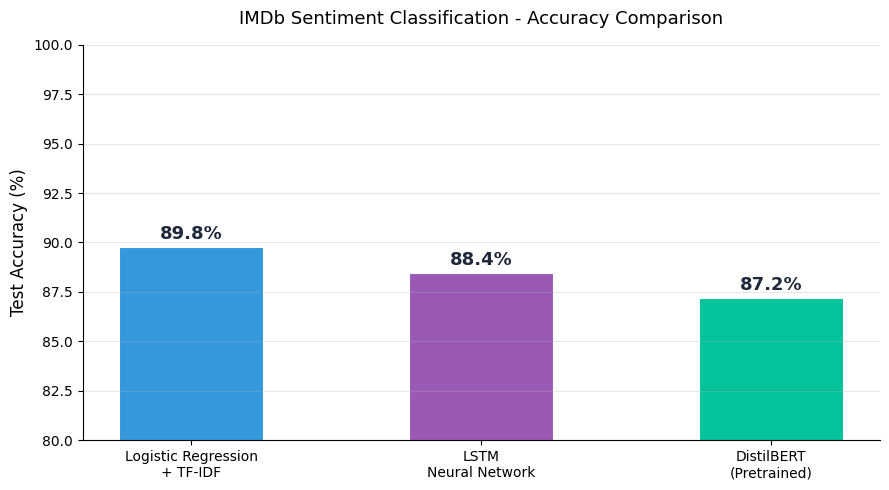

Chart saved as model_comparison.png


In [58]:
# Visualize the accuracy comparison as a bar chart

import matplotlib.pyplot as plt

model_names = [
    "Logistic Regression\n+ TF-IDF",
    "LSTM\nNeural Network",
    "DistilBERT\n(Pretrained)"
]
accuracies = [
    acc_lr * 100,
    acc_lstm * 100,
    acc_bert * 100
]
colors = ["#3498db", "#9b59b6", "#02c39a"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(model_names, accuracies, color=colors, width=0.5, edgecolor="white", linewidth=1.5)

# Add accuracy labels on top of bars
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{acc:.1f}%",
        ha="center", va="bottom",
        fontsize=13, fontweight="bold", color="#1e293b"
    )

ax.set_ylim(80, 100)
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("IMDb Sentiment Classification - Accuracy Comparison", fontsize=13, pad=15)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

print("Chart saved as model_comparison.png")

In [59]:
# Show where each model agrees and disagrees on individual reviews
# This builds intuition for what each model does differently

# Encode a set of reviews for LSTM
tricky_reviews = [
    "This is not a bad film at all. Actually quite enjoyable.",
    "I wanted to like it but the second half completely fell apart.",
    "The worst masterpiece I have ever seen. Painfully good.",
    "Boring, slow, and utterly predictable from start to finish.",
    "A surprisingly touching and beautifully crafted piece of cinema.",
]

# Logistic Regression predictions
lr_preds = lr_model.predict(tfidf.transform(tricky_reviews))
lr_probs = lr_model.predict_proba(tfidf.transform(tricky_reviews))

# LSTM predictions
lstm_preds = []
lstm_scores = []
for review in tricky_reviews:
    enc = encode_review(review, word_index)
    score = lstm_model.predict(enc, verbose=0)[0][0]
    lstm_scores.append(score)
    lstm_preds.append(1 if score > 0.5 else 0)

# DistilBERT predictions
bert_results = sentiment_pipeline(tricky_reviews, truncation=True, max_length=512)
bert_preds = [1 if r["label"] == "POSITIVE" else 0 for r in bert_results]

print("Model disagreement analysis on tricky reviews:")
print()

for i, review in enumerate(tricky_reviews):
    lr_label    = "POS" if lr_preds[i] == 1 else "NEG"
    lstm_label  = "POS" if lstm_preds[i] == 1 else "NEG"
    bert_label  = "POS" if bert_preds[i] == 1 else "NEG"
    agree = "ALL AGREE" if lr_label == lstm_label == bert_label else "MODELS DISAGREE"
    print(f"  Review: {review}")
    print(f"    LR: {lr_label}   LSTM: {lstm_label}   BERT: {bert_label}   -> {agree}")
    print()

Model disagreement analysis on tricky reviews:

  Review: This is not a bad film at all. Actually quite enjoyable.
    LR: NEG   LSTM: POS   BERT: POS   -> MODELS DISAGREE

  Review: I wanted to like it but the second half completely fell apart.
    LR: NEG   LSTM: POS   BERT: NEG   -> MODELS DISAGREE

  Review: The worst masterpiece I have ever seen. Painfully good.
    LR: NEG   LSTM: POS   BERT: POS   -> MODELS DISAGREE

  Review: Boring, slow, and utterly predictable from start to finish.
    LR: NEG   LSTM: POS   BERT: NEG   -> MODELS DISAGREE

  Review: A surprisingly touching and beautifully crafted piece of cinema.
    LR: POS   LSTM: POS   BERT: POS   -> ALL AGREE



---
## Key Takeaways - When to Use Each Approach

**Approach 1 - Logistic Regression + TF-IDF**

Use this when:
- You need a fast baseline to get started
- Your dataset is small (less than 10,000 examples)
- You need to explain your model to non-technical stakeholders (interpretable weights)
- You have limited compute resources
- Inference speed matters (thousands of predictions per second)

---

**Approach 2 - LSTM**

Use this when:
- Word order matters for your task (e.g. negation: 'not good')
- You are working on sequence tasks beyond classification (e.g. text generation)
- You have a medium-sized dataset and a GPU available
- You want more control over the model architecture

---

**Approach 3 - Pretrained Transformer (BERT, DistilBERT)**

Use this when:
- Accuracy is the top priority
- You have compute resources (GPU recommended for production)
- You want strong results with minimal labeled data
- You are working on a well-studied task where fine-tuned models exist

---

**The most honest answer:** In real projects, you almost always start with Approach 1,
check if the accuracy is good enough, and only move to Approach 3 if you need more.
The jump from ~89% to ~95% accuracy sounds small but can matter a lot in production.

---
## Summary - What We Covered in Demo 2

| Step | What we did |
|------|------------|
| 0 | Installed libraries, loaded IMDb dataset |
| 1 | Explored the dataset - 50,000 reviews, binary labels |
| 2 | Approach 1 - trained Logistic Regression with TF-IDF |
| 3 | Inspected learned word weights - the model is interpretable |
| 4 | Approach 2 - built and trained a 3-layer LSTM |
| 5 | Plotted training curves to check for overfitting |
| 6 | Approach 3 - loaded pretrained DistilBERT, zero training needed |
| 7 | Compared all three models on the same test set |
| 8 | Tested all three models on tricky reviews to see where they disagree |

---

**The full pipeline we built across Demo 1 and Demo 2:**

```
Raw text
   |
   v
Clean and preprocess  (Demo 1 - spaCy)
   |
   v
Convert to numbers  (TF-IDF  or  integer sequences  or  BERT tokens)
   |
   v
Train or load a model  (Logistic Regression  or  LSTM  or  DistilBERT)
   |
   v
Predict on new text  (positive or negative)
```

This pipeline is the backbone of almost every NLP system in production today.